(03-11-apt-no-arbitrage)=

# Ross, APT en de fundamentele stelling

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1976–1986.

**Wat we al weten.** Het CAPM uit [](#02-08-capm) prijst risico met één getal,
de bèta ten opzichte van de marktportefeuille, maar koopt dat met zware
aannames: mean-variance-beleggers, homogene verwachtingen en een markt die we
niet kunnen waarnemen. Black, Scholes en Merton lieten in [](#02-09-black-scholes)
zien dat je een optie kunt prijzen zonder iets over voorkeuren te weten, door
haar na te bouwen uit aandeel en obligatie. En Merton gaf in
[](#03-10-merton-icapm) het CAPM meer factoren, maar die factoren kwamen uit de
hedgebehoeften van een belegger wiens nutsfunctie we moeten kennen.

**Welke vraag staat open.** Hoeveel kunnen we over prijzen zeggen als we alleen
aannemen dat er geen geld op straat ligt?
```

## Overzicht

Pedro Santa-Clara noemt het het derde grote idee van het vak, na efficiëntie en
evenwicht: *"two things with the same payoffs must have the same price"*
{cite}`SantaClara2026`. Als dat niet zo was, kocht je het goedkope, verkocht je
het dure, en streek je het verschil op zonder risico en zonder kapitaal. Dat is
een *arbitrage* (een handelsstrategie die niets kost en in geen enkele toestand
verlies oplevert, maar in minstens één toestand winst), en in een markt met ook
maar een paar oplettende handelaren houdt die het niet lang uit.

Deze lecture laat zien hoe ver dat ene zinnetje draagt. Stephen Ross toonde in
1976 dat een lineaire factorstructuur plus de afwezigheid van arbitrage lineaire
verwachte rendementen oplevert — de *Arbitrage Pricing Theory* (APT) — zonder
één woord over wie welke portefeuille houdt {cite}`Ross1976`. Met John Cox
maakte hij in hetzelfde jaar het idee expliciet dat prijzen verwachtingen zijn
onder een andere kansmaat, één waaronder elk activum de risicovrije rente
verdient {cite}`CoxRoss1976`; met Cox en Mark Rubinstein goot hij dat in 1979 in
de binomiale boom die elke student sindsdien leert {cite}`CoxRossRubinstein1979`.
Michael Harrison, David Kreps en Stanley Pliska bewezen de stellingen: geen
arbitrage dan en slechts dan als er een equivalente martingaalmaat bestaat, en
unieke prijzen dan en slechts dan als de markt compleet is
{cite}`HarrisonKreps1979,HarrisonPliska1981`. Philip Dybvig en Ross gaven het
geheel in 1987 zijn naam: de *fundamentele stelling van asset pricing*
{cite}`DybvigRoss1987`.

Dit tijdvak verandert de epistemische status van een prijsmodel. Het CAPM is een
theorie die getoetst wordt en kan falen; de fundamentele stelling is een
wiskundige equivalentie en kan dat niet. Zij zegt dat élk arbitragevrij
prijssysteem te schrijven is als $p = \E[mx]$ met een positieve $m$, maar niet
welke $m$ — de kiem van het SDF-pluralisme dat Deel V uitwerkt. De APT
zit ertussenin: meer inhoud dan de stelling (er is een factorstructuur), minder
dan het CAPM (welke factoren en hoeveel, zegt zij niet). Precies die leegte werd
in de jaren tachtig het debat.

We rekenen eerst met de hand een markt met twee toestanden en drie activa door,
bewijzen dan de fundamentele stelling, leiden de APT af en tonen waarom de
binomiale boom naar Black-Scholes convergeert. Na een simulatie van die
convergentie, van pricing errors en van factorschatting met veel aandelen,
voeren we een principale-componentenanalyse uit op de 25 size/BM-portefeuilles
van French, vergelijken de eerste drie componenten met Mkt, SMB en HML, en
schatten in de geest van {cite:t}`RollRoss1980` hoeveel ervan een premie dragen.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Neem een markt waarin morgen maar twee dingen kunnen gebeuren: het gaat goed of
het gaat slecht. Er is een obligatie die in beide gevallen hetzelfde uitkeert,
en een aandeel dat in de goede toestand veel en in de slechte weinig uitkeert.
Met die twee kun je elke denkbare uitkering morgen namaken: wil je alleen iets
in de goede toestand, koop dan aandelen en verkoop precies zoveel obligaties dat
de slechte toestand op nul uitkomt. Een derde activum — een optie, een
verzekering, wat dan ook — voegt dus niets toe wat er niet al was. Zijn prijs
ligt vast: het moet evenveel kosten als het pakketje dat hetzelfde uitkeert.
Wijkt hij af, dan verkoop je het dure en koop je het goedkope: geld vandaag,
niets te betalen morgen.

Draai het nu om. Als alle prijzen onderling consistent zijn, dan moet er een
lijstje met twee getallen bestaan — de prijs van "één euro alleen als het goed
gaat" en de prijs van "één euro alleen als het slecht gaat" — waarmee je elke
prijs uitrekent als de som van uitkering maal toestandsprijs. Die getallen
moeten positief zijn: een claim die alleen in de slechte toestand iets oplevert,
mag niet gratis of negatief geprijsd zijn, want dan neem je er oneindig veel van.
Dat is de hele fundamentele stelling: *geen gratis geld* is hetzelfde als *er
bestaan positieve toestandsprijzen*. Deel je die prijzen door de kansen, dan heb
je een stochastic discount factor; normaliseer je ze tot ze optellen tot één, dan
heb je een alternatieve set "kansen" waaronder elk activum gemiddeld de
risicovrije rente oplevert. Drie namen voor één object.

Het tweede idee is dat van Ross over factoren, en het is subtieler. Aandelen
bewegen samen omdat een handvol grote krachten — de conjunctuur, de rente, de
olieprijs — ze allemaal raakt, en daarnaast beweegt elk aandeel om eigen
redenen. Met honderden aandelen kun je een portefeuille bouwen die niet
blootstaat aan de grote krachten en waarin de eigen bewegingen elkaar
uitmiddelen. Zo'n portefeuille is bijna risicovrij. Als hij toch een hoog
verwacht rendement had, lag er bijna-gratis geld. Dus moeten verwachte rendementen,
op een paar uitzonderingen na, bepaald zijn door de blootstelling aan de grote
krachten alleen. Dat "bijna" is de reden dat de APT losse aandelen niet kan
prijzen, alleen gespreide portefeuilles.

Dat Ross in 1986 met Richard Roll een vermogensbeheerder oprichtte om de APT aan
pensioenfondsen te verkopen {cite}`SantaClara2026`, is meer dan kleur: een
theorie die zegt dat alleen factorrisico beloond wordt, is een bouwtekening voor
risicomodellen.

```{note}
In hun lemma "Arbitrage" in *The New Palgrave* (1987) formuleerden Dybvig en Ross
de equivalentie van drie uitspraken — geen arbitrage, een positieve lineaire
prijsregel, en een optimale portefeuille voor ten minste één belegger die meer
verkiest boven minder — als de fundamentele stelling van asset pricing
{cite}`DybvigRoss1987`. De derde verbindt de stelling met evenwicht:
arbitragevrije prijzen zijn prijzen die íémand rationeel kan aanvaarden.
```

## Toy-voorbeeld: twee toestanden, drie activa en een arbitrage

Morgen is de toestand "goed" (fysieke kans $0{,}6$) of "slecht" (kans $0{,}4$).
Er zijn drie activa. De obligatie en het aandeel worden verhandeld tegen de
prijzen hieronder; het derde activum is een call-optie op het aandeel met
uitoefenprijs $1$, en zijn prijs is de vraag.

| Activum | payoff goed | payoff slecht | prijs $p$ |
|---|---|---|---|
| obligatie | 1{,}00 | 1{,}00 | 0{,}90 |
| aandeel | 1{,}40 | 0{,}60 | 0{,}86 |
| call ($K = 1$) | 0{,}40 | 0{,}00 | ? |

**Toestandsprijzen.** Noem $q_g$ en $q_s$ de prijzen van één euro alleen in de
goede respectievelijk alleen in de slechte toestand. Elke prijs is uitkering maal
toestandsprijs:

$$
\begin{aligned}
0{,}90 &= 1{,}00\, q_g + 1{,}00\, q_s \\
0{,}86 &= 1{,}40\, q_g + 0{,}60\, q_s
\end{aligned}
$$

Trek $0{,}6$ keer de eerste vergelijking van de tweede af: $0{,}80\, q_g = 0{,}86 -
0{,}54 = 0{,}32$, dus $q_g = 0{,}40$ en $q_s = 0{,}50$. Beide zijn positief; we
zullen zien dat dit precies de voorwaarde voor arbitragevrijheid is. De
risicovrije rente volgt uit de obligatie: $R^{f} = 1/(q_g + q_s) = 1/0{,}90 =
1{,}1111$.

**De call.** Zijn prijs is nu geen keuze meer: $p_{\text{call}} = 0{,}40 \cdot
0{,}40 + 0{,}50 \cdot 0 = 0{,}16$. Dezelfde prijs volgt uit replicatie. Zoek
$\theta_b$ obligaties en $\theta_a$ aandelen met dezelfde payoff:
$\theta_b + 1{,}40\,\theta_a = 0{,}40$ en $\theta_b + 0{,}60\,\theta_a = 0$.
Aftrekken geeft $0{,}80\,\theta_a = 0{,}40$, dus $\theta_a = 0{,}5$ (de delta)
en $\theta_b = -0{,}3$. Dat pakket kost $-0{,}3 \cdot 0{,}90 + 0{,}5 \cdot 0{,}86
= -0{,}27 + 0{,}43 = 0{,}16$.

**Risiconeutrale kansen.** Normaliseer de toestandsprijzen tot ze optellen tot
één: $\pi^{*}_g = 0{,}40/0{,}90 = 0{,}4444$ en $\pi^{*}_s = 0{,}5556$. Onder die
kansen verdient alles de risicovrije rente: het aandeel levert verwacht
$0{,}4444 \cdot 1{,}40 + 0{,}5556 \cdot 0{,}60 = 0{,}9556$ op, en
$0{,}9556/0{,}86 = 1{,}1111 = R^{f}$. De call kost
$\E^{*}[x]/R^{f} = 0{,}4444 \cdot 0{,}40 \cdot 0{,}90 = 0{,}16$. Onder de
*fysieke* kansen verdient het aandeel $(0{,}6 \cdot 1{,}40 + 0{,}4 \cdot
0{,}60)/0{,}86 = 1{,}08/0{,}86 = 1{,}2558$: een risicopremie van ruim 14
procentpunt. De risiconeutrale kansen leggen meer gewicht op de slechte toestand
dan de echte kansen; daarin zit de hele risicopremie.

**De SDF.** Deel de toestandsprijzen door de fysieke kansen:
$m_g = 0{,}40/0{,}6 = 0{,}6667$ en $m_s = 0{,}50/0{,}4 = 1{,}2500$. Nu is elke
prijs $p = \E[mx]$; voor de call $0{,}6 \cdot 0{,}6667 \cdot 0{,}40 = 0{,}16$. De
SDF is hoog in de slechte toestand: een euro is meer waard wanneer het slecht
gaat.

**Een arbitrage.** Stel de call noteert $0{,}20$ in plaats van $0{,}16$. Verkoop
één call ($+0{,}20$), koop een half aandeel ($-0{,}43$), en verkoop $0{,}3$
obligaties ($+0{,}27$). Vandaag ontvangen we $0{,}04$. Morgen in de goede toestand
betalen we $0{,}40$ aan de koper van de call, is het halve aandeel $0{,}70$ waard
en lossen we $0{,}30$ af: netto nul. In de slechte toestand: $0 + 0{,}30 - 0{,}30 =
0$. Vijfentwintig keer uitgevoerd is dat een euro vandaag, zonder enig risico.
Noteert de call onder $0{,}16$, dan draaien we alle posities om.

In [2]:
states = ["goed", "slecht"]
prob = np.array([0.6, 0.4])                 # physical probabilities
X = np.array([[1.00, 1.40, 0.40],           # payoffs in state 'goed'
              [1.00, 0.60, 0.00]])          # payoffs in state 'slecht'
p_traded = np.array([0.90, 0.86])           # prices of bond and stock

q = np.linalg.solve(X[:, :2].T, p_traded)   # p = X'q for the traded assets
R_f = 1 / q.sum()
q_rn = q * R_f                              # risk-neutral probabilities
m = q / prob                                # stochastic discount factor
theta = np.linalg.solve(X[:, :2], X[:, 2])  # replicating portfolio of the call

pd.DataFrame(
    {"toestandsprijs q": q, "risiconeutrale kans": q_rn,
     "fysieke kans": prob, "SDF m": m},
    index=states,
).round(4)

,toestandsprijs q,risiconeutrale kans,fysieke kans,SDF m
goed,0.4,0.4444,0.6,0.6667
slecht,0.5,0.5556,0.4,1.2500


In [3]:
call_prices = {
    "via toestandsprijzen q'x": q @ X[:, 2],
    "via SDF E[m x]": prob @ (m * X[:, 2]),
    "via risiconeutraal E*[x]/R^f": q_rn @ X[:, 2] / R_f,
    "via replicatie": theta @ p_traded,
}
assert np.allclose(q, [0.40, 0.50]) and np.allclose(m, [2 / 3, 1.25])
assert np.allclose(list(call_prices.values()), 0.16)
assert np.allclose(theta, [-0.3, 0.5])

pd.Series({**call_prices, "R^f": R_f, "obligaties in replicatie": theta[0],
           "aandelen in replicatie (delta)": theta[1]}).round(4)

via toestandsprijzen q'x          0.1600
via SDF E[m x]                    0.1600
via risiconeutraal E*[x]/R^f      0.1600
via replicatie                    0.1600
R^f                               1.1111
obligaties in replicatie         -0.3000
aandelen in replicatie (delta)    0.5000
dtype: float64

In [4]:
p_quoted = np.array([0.90, 0.86, 0.20])      # the call is overpriced
holdings = np.array([theta[0], theta[1], -1.0])

pd.DataFrame(
    {"kasstroom vandaag": [-holdings @ p_quoted],
     "payoff goed": [X[0] @ holdings],
     "payoff slecht": [X[1] @ holdings]},
    index=["short call + replicatie"],
).round(4)

,kasstroom vandaag,payoff goed,payoff slecht
short call + replicatie,0.04,0.0,0.0


Alle vier de routes geven $0{,}16$, de SDF is $(0{,}6667;\ 1{,}2500)$ en de
arbitragepositie levert vandaag $0{,}04$ op met payoff nul in beide toestanden:
de code reproduceert de handberekening exact. De fysieke kansen zijn nergens
nodig om de call te prijzen; dat is de observatie waarop {cite:t}`CoxRoss1976`
hun risiconeutrale waardering bouwden.

## Theorie

### Opzet en notatie

Eén periode, $S$ toestanden en $N$ activa. Omdat er maar één periode is, laten
we de tijdsindex weg: prijzen $p$ gelden op $t$, payoffs op $t+1$. De payoffs
staan in een $S \times N$-matrix $\mathbf{X}$ met element $X_{s,i}$, de uitkering
van activum $i$ in toestand $s$; de prijzen in $\mathbf{p} \in \mathbb{R}^{N}$.
Een portefeuille $\boldsymbol{\theta} \in \mathbb{R}^{N}$ (negatieve elementen
zijn short) kost $\mathbf{p}'\boldsymbol{\theta}$ en keert
$\mathbf{X}\boldsymbol{\theta} \in \mathbb{R}^{S}$ uit. De fysieke kansen zijn
$\pi_s > 0$. Voor vectoren schrijven we $\mathbf{z} \geq \mathbf{0}$ als elk
element niet-negatief is en $\mathbf{z} \gg \mathbf{0}$ als elk element strikt
positief is.

:::{prf:definition} Arbitrage, toestandsprijzen, SDF, risiconeutrale maat
:label: def-apt-no-arbitrage-begrippen

1. Een *arbitrage* is een $\boldsymbol{\theta}$ met
   $\mathbf{p}'\boldsymbol{\theta} \leq 0$ en $\mathbf{X}\boldsymbol{\theta}
   \geq \mathbf{0}$, waarbij niet zowel $\mathbf{p}'\boldsymbol{\theta} = 0$ als
   $\mathbf{X}\boldsymbol{\theta} = \mathbf{0}$.
2. Een vector *state prices* (toestandsprijzen: de prijs van één euro in precies
   één toestand) is een $\mathbf{q} \gg \mathbf{0}$ met
   $\mathbf{p} = \mathbf{X}'\mathbf{q}$.
3. Een *stochastic discount factor* (SDF, stochastische disconteringsfactor: de
   willekeurige variabele waarmee je payoffs verdisconteert) is een $m$ met
   $p_i = \E[m x_i] = \sum_s \pi_s m_s X_{s,i}$ voor alle $i$.
4. Als er een portefeuille is met payoff $\mathbf{1}$ en prijs $1/R^{f}$, is een
   *equivalente martingaalmaat* (risiconeutrale maat) een kansvector
   $\boldsymbol{\pi}^{*} \gg \mathbf{0}$ met
   $p_i = \E^{*}[x_i]/R^{f}$ voor alle $i$.
:::

"Equivalent" betekent hier gewoon $\pi^{*}_s > 0$ in elke toestand; "martingaal"
verwijst naar de dynamische versie hieronder.

De drie objecten zijn vertalingen van elkaar. Gegeven $\mathbf{q} \gg \mathbf{0}$
is $m_s = q_s/\pi_s$ een strikt positieve SDF, en omgekeerd. En gegeven een
risicovrij activum is $\mathbf{1}/R^{f} = \mathbf{1}'\mathbf{q}$, dus
$\pi^{*}_s = q_s R^{f}$ telt op tot één. In formule:

```{math}
:label: eq-apt-no-arbitrage-drie-namen
p_i \;=\; \sum_{s} q_s X_{s,i}
    \;=\; \E\!\left[m\, x_i\right]
    \;=\; \frac{\E^{*}\!\left[x_i\right]}{R^{f}},
\qquad
m_s = \frac{q_s}{\pi_s},
\qquad
\pi^{*}_s = q_s R^{f}.
```

### De fundamentele stelling in eindig veel toestanden

*Waarom zou dit waar zijn?* Eén richting is onmiddellijk: als er positieve
toestandsprijzen zijn, kost elke payoff die nergens negatief en ergens positief
is een strikt positief bedrag, dus is er geen arbitrage. De andere richting is
de interessante. De verzameling haalbare combinaties (kosten vandaag, payoffs
morgen) is een lineaire deelruimte; "geen arbitrage" zegt dat die deelruimte de
positieve orthant alleen in de oorsprong raakt. Twee convexe verzamelingen die
elkaar niet raken, kun je scheiden met een hypervlak — en de normaalvector van
dat hypervlak blijkt precies het lijstje toestandsprijzen te zijn. De stelling is
dus in wezen meetkunde: arbitragevrije prijzen zijn een scheidend hypervlak.

:::{prf:theorem} Fundamentele stelling van asset pricing (eindig)
:label: thm-apt-no-arbitrage-fundamenteel

De volgende uitspraken zijn equivalent:

1. Er is geen arbitrage.
2. Er bestaan toestandsprijzen $\mathbf{q} \gg \mathbf{0}$ met
   $\mathbf{p} = \mathbf{X}'\mathbf{q}$.
3. Er bestaat een strikt positieve SDF: $m \gg 0$ met $\mathbf{p} =
   \E[m\,\mathbf{x}]$.

Als er een risicovrij activum is, zijn ze bovendien equivalent met

4. Er bestaat een equivalente martingaalmaat $\boldsymbol{\pi}^{*}$.
:::

Het bewijs gebruikt één stuk convexe analyse.

:::{prf:lemma} Scheidend hypervlak
:label: lem-apt-no-arbitrage-scheiding

Laat $A \subset \mathbb{R}^{n}$ gesloten en convex zijn en $B \subset
\mathbb{R}^{n}$ compact en convex, met $A \cap B = \emptyset$. Dan bestaat er
een $\boldsymbol{\phi} \in \mathbb{R}^{n}$ en scalairen $c_1 < c_2$ met
$\boldsymbol{\phi}'\mathbf{a} \leq c_1$ voor alle $\mathbf{a} \in A$ en
$\boldsymbol{\phi}'\mathbf{b} \geq c_2$ voor alle $\mathbf{b} \in B$.
:::

:::{prf:proof}
:class: dropdown

**(2) ⇒ (1).** Stel $\mathbf{p} = \mathbf{X}'\mathbf{q}$ met $\mathbf{q} \gg
\mathbf{0}$ en neem een $\boldsymbol{\theta}$ met $\mathbf{X}\boldsymbol{\theta}
\geq \mathbf{0}$. Dan is $\mathbf{p}'\boldsymbol{\theta} =
\mathbf{q}'\mathbf{X}\boldsymbol{\theta} \geq 0$, met gelijkheid alleen als
$\mathbf{X}\boldsymbol{\theta} = \mathbf{0}$ (want elke $q_s > 0$). Een
portefeuille met niet-positieve kosten en niet-negatieve payoff heeft dus kosten
nul en payoff nul: geen arbitrage.

**(1) ⇒ (2).** Definieer de lineaire deelruimte

$$
M = \left\{ \left(-\mathbf{p}'\boldsymbol{\theta},\;
      \mathbf{X}\boldsymbol{\theta}\right) : \boldsymbol{\theta} \in
      \mathbb{R}^{N} \right\} \subset \mathbb{R}^{1+S}.
$$

Het eerste element is de kasstroom vandaag, de overige $S$ de kasstromen morgen.
Geen arbitrage betekent precies $M \cap \mathbb{R}^{1+S}_{+} = \{\mathbf{0}\}$:
er is geen vector in $M$ die overal niet-negatief is en ergens positief. Laat
$\Delta = \{\mathbf{z} \in \mathbb{R}^{1+S}_{+} : \sum_j z_j = 1\}$ de simplex
zijn. $\Delta$ is compact en convex, $M$ is gesloten en convex (een eindig-
dimensionale deelruimte), en $M \cap \Delta = \emptyset$ omdat $\mathbf{0} \notin
\Delta$. [](#lem-apt-no-arbitrage-scheiding) geeft een $\boldsymbol{\phi}$ met
$\boldsymbol{\phi}'\mathbf{y} \leq c_1 < c_2 \leq \boldsymbol{\phi}'\mathbf{z}$
voor alle $\mathbf{y} \in M$, $\mathbf{z} \in \Delta$.

Omdat $M$ een deelruimte is, zit $\lambda\mathbf{y}$ in $M$ voor elke
$\lambda \in \mathbb{R}$; een lineaire functie die op een deelruimte naar boven
begrensd is, is daar nul. Dus $\boldsymbol{\phi}'\mathbf{y} = 0$ op heel $M$, en
we mogen $c_1 = 0$ nemen, zodat $c_2 > 0$. Neem voor $\mathbf{z}$ de
eenheidsvectoren $\mathbf{e}_j \in \Delta$: $\phi_j \geq c_2 > 0$ voor elke $j$.
Dus $\boldsymbol{\phi} \gg \mathbf{0}$.

Schrijf $\boldsymbol{\phi} = (\phi_0, \boldsymbol{\phi}_{1:S})$. Orthogonaliteit
aan $M$ zegt $-\phi_0\,\mathbf{p}'\boldsymbol{\theta} +
\boldsymbol{\phi}_{1:S}'\mathbf{X}\boldsymbol{\theta} = 0$ voor álle
$\boldsymbol{\theta}$, dus $\phi_0\,\mathbf{p} = \mathbf{X}'\boldsymbol{\phi}_{1:S}$.
Deel door $\phi_0 > 0$: $\mathbf{q} = \boldsymbol{\phi}_{1:S}/\phi_0 \gg
\mathbf{0}$ voldoet aan $\mathbf{p} = \mathbf{X}'\mathbf{q}$.

**(2) ⇔ (3) ⇔ (4)** volgen uit de vertalingen in
[](#eq-apt-no-arbitrage-drie-namen): $m_s = q_s/\pi_s$ is strikt positief precies
dan als $q_s$ dat is, en met een risicovrij activum (payoff $\mathbf{1}$, prijs
$\mathbf{1}'\mathbf{q} = 1/R^{f}$) is $\pi^{*}_s = q_s R^{f}$ een strikt positieve
kansvector die [](#eq-apt-no-arbitrage-drie-namen) oplost, en omgekeerd.
$\square$
:::

```{note}
Het bewijs is een variant van het lemma van Farkas, in de vorm die Stiemke al in
1915 gaf: precies één van de twee systemen "$\mathbf{X}'\mathbf{q} = \mathbf{p}$,
$\mathbf{q} \gg \mathbf{0}$" en "$\mathbf{p}'\boldsymbol{\theta} \leq 0$,
$\mathbf{X}\boldsymbol{\theta} \geq \mathbf{0}$, niet beide nul" heeft een
oplossing. In het toy-voorbeeld met de call op $0{,}20$ heeft het eerste systeem
geen oplossing (de enige $\mathbf{q}$ die obligatie en aandeel prijst, geeft de
call $0{,}16$), dus heeft het tweede er een — en die hebben we hierboven
opgeschreven.
```

### Complete en incomplete markten

*Waarom zou dit waar zijn?* De toestandsprijzen zijn de oplossing van $S$
onbekenden uit $N$ vergelijkingen. Als de activa elke payoff kunnen namaken, zijn
er genoeg vergelijkingen om de $S$ prijzen vast te pinnen. Kunnen ze dat niet,
dan is er een richting in de toestandsruimte die geen enkel activum "ziet", en
langs die richting kun je de toestandsprijzen verschuiven zonder één
waargenomen prijs te veranderen. Dan zijn er meerdere SDF's, en een payoff die
buiten het bereik van de markt valt, heeft een *interval* van arbitragevrije
prijzen in plaats van één prijs.

:::{prf:theorem} Volledigheid en uniciteit
:label: thm-apt-no-arbitrage-uniek

Stel dat er geen arbitrage is. De markt heet *compleet* als elke payoff
$\mathbf{y} \in \mathbb{R}^{S}$ te repliceren is, d.w.z. $\operatorname{rang}
\mathbf{X} = S$. Dan geldt: de toestandsprijzen (en dus de SDF en de
risiconeutrale maat) zijn uniek dan en slechts dan als de markt compleet is.
In een incomplete markt is de prijs van een niet-repliceerbare payoff
$\mathbf{y}$ niet vastgelegd; elke waarde in het open interval

```{math}
:label: eq-apt-no-arbitrage-grenzen
\left( \inf_{\mathbf{q} \gg \mathbf{0},\; \mathbf{X}'\mathbf{q} = \mathbf{p}}
       \mathbf{q}'\mathbf{y},\;\;
       \sup_{\mathbf{q} \gg \mathbf{0},\; \mathbf{X}'\mathbf{q} = \mathbf{p}}
       \mathbf{q}'\mathbf{y} \right)
```

is consistent met afwezigheid van arbitrage.
:::

:::{prf:proof}
:class: dropdown

De oplossingen van $\mathbf{X}'\mathbf{q} = \mathbf{p}$ vormen de affiene
verzameling $\mathbf{q}_0 + \ker \mathbf{X}'$, en $\ker \mathbf{X}' = \{\mathbf{0}\}$
precies als $\mathbf{X}'$ (een $N \times S$-matrix) rang $S$ heeft, d.w.z. als
$\mathbf{X}$ rang $S$ heeft. Is de rang $S$, dan is er dus hoogstens één oplossing,
en door [](#thm-apt-no-arbitrage-fundamenteel) precies één strikt positieve.
Is de rang kleiner, dan is $\ker \mathbf{X}' \neq \{\mathbf{0}\}$; neem een
$\mathbf{k} \neq \mathbf{0}$ daarin. Voor een strikt positieve oplossing
$\mathbf{q}_0$ is $\mathbf{q}_0 + \varepsilon\mathbf{k}$ ook strikt positief
voor $|\varepsilon|$ klein genoeg, en het prijst alle activa: niet uniek.

Voor de prijsgrenzen: voeg $\mathbf{y}$ met prijs $p_y$ toe aan de markt. Door
[](#thm-apt-no-arbitrage-fundamenteel) is de uitgebreide markt arbitragevrij
precies dan als er een $\mathbf{q} \gg \mathbf{0}$ is met $\mathbf{X}'\mathbf{q}
= \mathbf{p}$ én $\mathbf{q}'\mathbf{y} = p_y$. De verzameling
$\{\mathbf{q}'\mathbf{y} : \mathbf{q} \gg \mathbf{0}, \mathbf{X}'\mathbf{q} =
\mathbf{p}\}$ is het beeld van een convexe verzameling onder een lineaire functie,
dus een interval; het is open omdat de verzameling van strikt positieve
oplossingen relatief open is in haar affiene omhulsel. $\square$
:::

Het supremum in [](#eq-apt-no-arbitrage-grenzen) is, via de dualiteitsstelling
van lineaire programmering, de kostprijs van de goedkoopste portefeuille die
overal minstens $\mathbf{y}$ uitkeert: de *super-replicatieprijs* (zie
[](#ex-apt-no-arbitrage-1)). Echte markten zijn incompleet; de stelling
garandeert dan een positieve SDF, maar niet welke.

### Van één periode naar een boom: Harrison en Kreps

*Waarom zou dit waar zijn?* Een boom met veel perioden is een aaneenschakeling
van één-periode-markten: in elke knoop kun je handelen, en wat je daar koopt, is
een claim op de prijzen in de volgende knopen. Als er nergens in de boom
arbitrage is, dan is er in elke knoop een set positieve toestandsprijzen voor de
takken die eruit vertrekken. Vermenigvuldig ze langs een pad, en je hebt een
maat op hele paden. Onder die maat is de verdisconteerde prijs van elk activum
een martingaal: de beste voorspelling van morgen, gedeeld door de rentegroei, is
vandaag.

Formeel, in een eindige boom met risicovrije bruto rente $R^{f}_{t+1}$ per
periode (bekend op $t$) en cum-dividendprijzen: geen arbitrage met dynamische
strategieën is equivalent met het bestaan van een $\boldsymbol{\pi}^{*}$ die elk
pad een positieve kans geeft en waaronder

```{math}
:label: eq-apt-no-arbitrage-martingaal
\frac{p_t}{B_t} = \E^{*}_t\!\left[\frac{p_{t+1} + d_{t+1}}{B_{t+1}}\right],
\qquad
B_t = \prod_{u=1}^{t} R^{f}_{u},
```

wat na herschrijven $p_t = \E_t[m_{t+1}(p_{t+1} + d_{t+1})]$ is met een positieve
$m_{t+1}$. Dat is het resultaat van {cite:t}`HarrisonKreps1979`; in een eindige
boom is het bewijs [](#thm-apt-no-arbitrage-fundamenteel) toegepast op elke
knoop. {cite:t}`HarrisonPliska1981` brachten het naar continue tijd, waar
volledigheid samenvalt met uniciteit van de martingaalmaat.
{cite:t}`CoxRoss1976` hadden de praktische kant al gezien: omdat de
Black-Scholes-prijs geen risicoaversie bevat, mag je hem uitrekenen alsof
iedereen risiconeutraal is. Harrison en Kreps lieten zien waarom dat werkt: je
verandert niet de wereld, maar de kansmaat.

### De binomiale boom en de Black-Scholes-limiet

*Waarom zou dit waar zijn?* In de boom van [](#02-09-black-scholes) gaat het
aandeel per stap met factor $u$ omhoog of $d$ omlaag. Elke stap is ons
toy-voorbeeld: twee toestanden, obligatie en aandeel, een complete markt met
unieke risiconeutrale kansen. Maak de stappen kleiner met gelijkblijvende
variantie per tijdseenheid, en het logrendement wordt een som van veel kleine,
onafhankelijke stapjes; de centrale limietstelling maakt daar de normale
verdeling van Black en Scholes van.

In één stap met bruto rente $R = e^{r\Delta}$ geeft [](#eq-apt-no-arbitrage-drie-namen)
voor het aandeel $S = (\pi^{*} uS + (1-\pi^{*}) dS)/R$, dus

```{math}
:label: eq-apt-no-arbitrage-crr-q
\pi^{*} = \frac{R - d}{u - d},
```

en $\pi^{*} \in (0,1)$ — geen arbitrage — precies als $d < R < u$. Na $n$ stappen
van lengte $\Delta = T/n$ met $j$ keer omhoog geldt $S_T = S u^{j} d^{n-j}$, en de
prijs van een call met uitoefenprijs $K$ is de risiconeutrale verwachting

```{math}
:label: eq-apt-no-arbitrage-crr
C_n = e^{-rT} \sum_{j=0}^{n} \binom{n}{j} (\pi^{*})^{j} (1-\pi^{*})^{n-j}
      \max\!\left(S u^{j} d^{n-j} - K,\ 0\right).
```

{cite:t}`CoxRossRubinstein1979` kozen $u = e^{\sigma\sqrt{\Delta}}$ en $d = 1/u$.

:::{prf:theorem} Van Cox-Ross-Rubinstein naar Black-Scholes
:label: thm-apt-no-arbitrage-crr-bs

Met $u = e^{\sigma\sqrt{\Delta}}$, $d = 1/u$, $R = e^{r\Delta}$ en $\Delta = T/n$
geldt $C_n \to C^{\mathrm{BS}}$ als $n \to \infty$, met

$$
C^{\mathrm{BS}} = S\,\Phi(d_1) - K e^{-rT}\Phi(d_2),
\qquad
d_{1,2} = \frac{\log(S/K) + (r \pm \tfrac12\sigma^2)T}{\sigma\sqrt{T}}.
$$
:::

:::{prf:proof}
:class: dropdown

Schrijf $\log S_T = \log S + \sum_{k=1}^{n}\xi_k$ met $\xi_k$ onafhankelijk onder
de risiconeutrale maat, $\xi_k = +\sigma\sqrt{\Delta}$ met kans $\pi^{*}$ en
$-\sigma\sqrt{\Delta}$ met kans $1-\pi^{*}$.

*Stap 1: de kans.* Taylor-ontwikkeling tot orde $\Delta$ geeft
$e^{r\Delta} - e^{-\sigma\sqrt\Delta} = \sigma\sqrt\Delta + (r - \tfrac12\sigma^2)\Delta
+ O(\Delta^{3/2})$ en $e^{\sigma\sqrt\Delta} - e^{-\sigma\sqrt\Delta} = 2\sigma\sqrt\Delta
+ O(\Delta^{3/2})$, dus

$$
\pi^{*} = \tfrac12 + \frac{r - \tfrac12\sigma^2}{2\sigma}\sqrt{\Delta} + O(\Delta).
$$

*Stap 2: de momenten.* $\E^{*}[\xi_k] = (2\pi^{*} - 1)\sigma\sqrt\Delta = (r -
\tfrac12\sigma^2)\Delta + O(\Delta^{3/2})$ en $\Var^{*}(\xi_k) = \sigma^2\Delta -
(\E^{*}[\xi_k])^2 = \sigma^2\Delta + O(\Delta^2)$. Opgeteld over $n = T/\Delta$
stappen: gemiddelde $(r - \tfrac12\sigma^2)T + O(\sqrt\Delta)$, variantie
$\sigma^2 T + O(\Delta)$.

*Stap 3: normaliteit.* De $\xi_k$ vormen een driehoeksrij met $|\xi_k| \leq
\sigma\sqrt\Delta \to 0$; de Lindeberg-voorwaarde is dus triviaal vervuld, en
$\sum_k \xi_k \Rightarrow \mathcal{N}\big((r - \tfrac12\sigma^2)T,\ \sigma^2 T\big)$.

*Stap 4: verwachtingen.* De payoff $g(s) = \max(e^{s} - K, 0)$ is continu, dus
$g(\log S_T)$ convergeert in verdeling. Ze is gedomineerd door $S_T$, en
$\E^{*}[S_T^2] = S^2\big(\pi^{*}u^2 + (1-\pi^{*})d^2\big)^n$ blijft begrensd (de
logaritme van de basis is $(2r + \sigma^2)\Delta + O(\Delta^{3/2})$). Begrensde
tweede momenten geven uniforme integreerbaarheid, dus ook de verwachtingen
convergeren. De limiet is $e^{-rT}\E[\max(S_T - K, 0)]$ met $\log S_T$ normaal
zoals in stap 3, en die integraal is de Black-Scholes-formule. $\square$
:::

Over de *snelheid* zegt het bewijs niets; de simulatie laat zien dat die orde
$1/n$ is, en niet monotoon.

### De APT: exacte factorstructuur

*Waarom zou dit waar zijn?* Het toy-voorbeeld had drie activa en twee
toestanden; het derde activum was een lineaire combinatie van de eerste twee en
had daardoor geen vrije prijs. Ross zag dat hetzelfde argument werkt als je
"toestanden" vervangt door "factoren". Als elk rendement een constante plus een
lineaire combinatie van $K$ gemeenschappelijke schokken is, zonder eigen ruis,
dan zijn er met $N > K+1$ activa portefeuilles die niets kosten en geen enkel
risico dragen. Hun verwachte rendement moet nul zijn — en dat legt de verwachte
rendementen van alle activa lineair vast in hun factorblootstellingen.

Laat de bruto rendementen voldoen aan

```{math}
:label: eq-apt-no-arbitrage-factormodel
R_i = \mu_i + \sum_{k=1}^{K} \beta_{i,k} f_k + \varepsilon_i,
\qquad \E[f_k] = 0,\quad \E[\varepsilon_i] = 0,\quad \Cov(f_k, \varepsilon_i) = 0,
```

in matrixvorm $\mathbf{R} = \boldsymbol{\mu} + \mathbf{B}\mathbf{f} +
\boldsymbol{\varepsilon}$, met $\mathbf{B}$ de $N \times K$-matrix van *factor
loadings* (factorbelastingen: de gevoeligheden $\beta_{i,k}$) en
$\boldsymbol{\Sigma} = \mathbf{B}\boldsymbol{\Omega}\mathbf{B}' + \mathbf{V}$,
$\boldsymbol{\Omega} = \Var(\mathbf{f})$, $\mathbf{V} = \Var(\boldsymbol{\varepsilon})$.
In deze sectie zijn de $f_k$ de *schokken* (verwachting nul); in de
replicatie zijn het factor-*rendementen* met een premie als verwachting. Een
portefeuille $\mathbf{w}$ met $\mathbf{w}'\mathbf{1} = 0$ kost niets (lenen en
beleggen tegen dezelfde prijs per euro) en levert $\mathbf{w}'\mathbf{R}$ op.

:::{prf:theorem} Exacte APT
:label: thm-apt-no-arbitrage-exact

Stel $\boldsymbol{\varepsilon} = \mathbf{0}$ in [](#eq-apt-no-arbitrage-factormodel)
en er is geen arbitrage. Dan bestaan $\lambda_0$ en $\boldsymbol{\lambda} \in
\mathbb{R}^{K}$ met

```{math}
:label: eq-apt-no-arbitrage-apt
\boldsymbol{\mu} = \lambda_0\mathbf{1} + \mathbf{B}\boldsymbol{\lambda}.
```
:::

:::{prf:proof}
Projecteer $\boldsymbol{\mu}$ orthogonaal op de kolommen van $[\mathbf{1},
\mathbf{B}]$: $\boldsymbol{\mu} = \lambda_0\mathbf{1} + \mathbf{B}\boldsymbol{\lambda}
+ \boldsymbol{\eta}$ met $\boldsymbol{\eta}'\mathbf{1} = 0$ en $\boldsymbol{\eta}'\mathbf{B}
= \mathbf{0}$. De portefeuille $\mathbf{w} = \boldsymbol{\eta}$ kost niets en
levert in elke toestand $\boldsymbol{\eta}'\mathbf{R} = \boldsymbol{\eta}'\boldsymbol{\mu}
+ \boldsymbol{\eta}'\mathbf{B}\mathbf{f} = \boldsymbol{\eta}'\boldsymbol{\eta}$
op. Is $\boldsymbol{\eta} \neq \mathbf{0}$, dan is dat een zeker, strikt positief
bedrag voor een portefeuille die niets kost: arbitrage. Dus $\boldsymbol{\eta} =
\mathbf{0}$. $\square$
:::

Als er een risicovrij activum is, is $\lambda_0 = R^{f}$ (het heeft $\beta = 0$), en
$\lambda_k$ is het extra verwachte rendement per eenheid blootstelling aan factor
$k$ — de *prijs van risico* uit de notatietabel. In excess rendementen:
$\E[R^{e}_i] = \sum_k \beta_{i,k}\lambda_k$.

```{prf:remark} APT en SDF
:label: rem-apt-no-arbitrage-sdf

Een factormodel met prijzen van risico is hetzelfde als een SDF die lineair is in
de factoren. Neem $m = a - \mathbf{b}'\mathbf{f}$ met $a = 1/R^{f}$ en
$\mathbf{b} = a\,\boldsymbol{\Omega}^{-1}\boldsymbol{\lambda}$. Dan is
$\E[m R^{e}_i] = a\,\E[R^{e}_i] - \mathbf{b}'\Cov(\mathbf{f}, R^{e}_i)
= a\left(\E[R^{e}_i] - \boldsymbol{\lambda}'\boldsymbol{\Omega}^{-1}\boldsymbol{\Omega}\boldsymbol{\beta}_i\right)$,
dat nul is precies als [](#eq-apt-no-arbitrage-apt) geldt. Maar let op: niets
garandeert dat deze lineaire $m$ positief is. Een lineaire factor-SDF prijst
de activa waarop hij geschat is, maar kan negatieve toestandsprijzen impliceren
voor een diep uit-het-geld optie op de factor. De APT is dus een zwakkere
uitspraak dan [](#thm-apt-no-arbitrage-fundamenteel): zij beperkt verwachte
rendementen, niet alle prijzen.
```

### De APT met ruis: Ross, Huberman en de grens op pricing errors

*Waarom zou dit waar zijn?* Met eigen ruis per aandeel is de portefeuille
$\boldsymbol{\eta}$ niet meer risicovrij, dus het argument hierboven werkt niet
exact. Maar de eigen ruis middelt uit: een portefeuille met gewichten van orde
$1/N$ heeft idiosyncratische variantie van orde $1/N$. Als de pricing errors
$\eta_i$ "groot en veel" zijn, kun je ze bundelen tot een portefeuille die
steeds meer verwacht rendement en steeds minder risico heeft naarmate $N$
groeit. Dat noemen we een *asymptotische arbitrage*. Wie die uitsluit, sluit
niet uit dat een enkel aandeel fors verkeerd geprijsd is — alleen dat er
oneindig veel zijn die het allemaal behoorlijk zijn.

{cite:t}`Huberman1982` gaf het argument van Ross een korte, sluitende vorm. We
werken in een rij economieën met de eerste $N$ activa uit een oneindige
rij, schrijven $\boldsymbol{\mu}^{N}$, $\mathbf{B}^{N}$, $\mathbf{V}^{N}$, en
nemen aan dat de idiosyncratische covariantiematrix een begrensde grootste
eigenwaarde heeft: $\lambda_{\max}(\mathbf{V}^{N}) \leq \bar\sigma^2$ voor alle
$N$. In de *strikte* factorstructuur van Ross is $\mathbf{V}^{N}$ diagonaal en is
dat de grootste idiosyncratische variantie; in de *benaderende* factorstructuur
van {cite:t}`ChamberlainRothschild1983` mag $\mathbf{V}^{N}$ niet-diagonaal zijn
— aandelen in dezelfde bedrijfstak mogen samen bewegen — zolang geen enkele
richting onbegrensd veel idiosyncratische variantie verzamelt.

:::{prf:definition} Asymptotische arbitrage
:label: def-apt-no-arbitrage-asymptotisch

Een rij portefeuilles $\mathbf{w}^{N}$ met $\mathbf{w}^{N\prime}\mathbf{1} = 0$ is een
asymptotische arbitrage als (langs een deelrij) $\E[\mathbf{w}^{N\prime}\mathbf{R}^{N}]
\to \infty$ en $\Var(\mathbf{w}^{N\prime}\mathbf{R}^{N}) \to 0$.
:::

:::{prf:theorem} Huberman-grens
:label: thm-apt-no-arbitrage-huberman

Laat $\boldsymbol{\eta}^{N}$ de residuen zijn van de orthogonale projectie van
$\boldsymbol{\mu}^{N}$ op $[\mathbf{1}, \mathbf{B}^{N}]$. Als
$\lambda_{\max}(\mathbf{V}^{N}) \leq \bar\sigma^2$ voor alle $N$ en er geen
asymptotische arbitrage bestaat, dan is er een $c < \infty$ met

```{math}
:label: eq-apt-no-arbitrage-huberman
\sum_{i=1}^{N} \left(\eta^{N}_{i}\right)^2 \;\leq\; c \qquad \text{voor alle } N.
```
:::

:::{prf:proof}
Stel dat de rij $\boldsymbol{\eta}^{N\prime}\boldsymbol{\eta}^{N}$ onbegrensd is en
neem een deelrij waarlangs zij naar oneindig gaat. Kies

$$
\mathbf{w}^{N} = \frac{\boldsymbol{\eta}^{N}}{\left(\boldsymbol{\eta}^{N\prime}\boldsymbol{\eta}^{N}\right)^{3/4}}.
$$

*Kosten.* $\mathbf{w}^{N\prime}\mathbf{1} = 0$ omdat $\boldsymbol{\eta}^{N} \perp \mathbf{1}$.
*Factorrisico.* $\mathbf{w}^{N\prime}\mathbf{B}^{N} = \mathbf{0}$ omdat
$\boldsymbol{\eta}^{N} \perp \mathbf{B}^{N}$, dus $\mathbf{w}^{N\prime}\mathbf{R}^{N} =
\mathbf{w}^{N\prime}\boldsymbol{\mu}^{N} + \mathbf{w}^{N\prime}\boldsymbol{\varepsilon}^{N}$.
*Verwachting.* $\mathbf{w}^{N\prime}\boldsymbol{\mu}^{N} = \mathbf{w}^{N\prime}\boldsymbol{\eta}^{N}
= (\boldsymbol{\eta}^{N\prime}\boldsymbol{\eta}^{N})^{1/4} \to \infty$, want de projectie op
$\mathbf{1}$ en $\mathbf{B}^N$ valt weg tegen $\mathbf{w}^N$.
*Variantie.* $\mathbf{w}^{N\prime}\mathbf{V}^{N}\mathbf{w}^{N} \leq \bar\sigma^2\,
\mathbf{w}^{N\prime}\mathbf{w}^{N} = \bar\sigma^2 (\boldsymbol{\eta}^{N\prime}\boldsymbol{\eta}^{N})^{-1/2}
\to 0$.

Dat is een asymptotische arbitrage, in strijd met de aanname. $\square$
:::

De coëfficiënten $\lambda_0^N$ en $\boldsymbol{\lambda}^N$ hangen hier van $N$ af;
dat ze vast gekozen kunnen worden, bewijzen we niet.

De grens [](#eq-apt-no-arbitrage-huberman) heeft twee consequenties, en ze wijzen
in tegengestelde richting.

1. **Gespreide portefeuilles worden goed geprijsd.** Een portefeuille met
   $\mathbf{w}'\mathbf{1} = 1$ heeft pricing error $\mathbf{w}'\boldsymbol{\eta}$, en
   door Cauchy-Schwarz is $|\mathbf{w}'\boldsymbol{\eta}| \leq \|\mathbf{w}\|\sqrt{c}$.
   Voor de gelijkgewogen portefeuille is $\|\mathbf{w}\| = 1/\sqrt{N}$, dus de
   fout is hoogstens $\sqrt{c/N} \to 0$.
2. **Losse aandelen niet noodzakelijk.** De grens verbiedt geen enkel aandeel om
   fors verkeerd geprijsd te zijn. Hij zegt alleen dat het *aantal* aandelen met
   $\eta_i^2 \geq \zeta$ hoogstens $c/\zeta$ is — een vast getal, dus een
   verdwijnende fractie als $N$ groeit.

Voor wie een aandeel wil prijzen, is de APT daarmee bijna leeg. Voor wie
portefeuilles bouwt, is ze bijna alles.

### Factoren schatten: Chamberlain-Rothschild en Connor-Korajczyk

*Waarom zou dit waar zijn?* In een factormodel is de covariantiematrix de som
van een matrix van lage rang $\mathbf{B}\boldsymbol{\Omega}\mathbf{B}'$ en de
idiosyncratische $\mathbf{V}$. Als elke factor veel aandelen raakt, groeien de
$K$ grootste eigenwaarden van de eerste term evenredig met $N$, terwijl die van
$\mathbf{V}$ begrensd blijven. Bij grote $N$ domineren dus $K$ richtingen de
covariantiematrix, en de eigenvectoren van die richtingen zijn — op een rotatie
na — de factor loadings. Principale componenten zijn in die wereld niet een
statistische truc maar een consistente schatter van de factoren.

{cite:t}`ChamberlainRothschild1983` maakten dat precies: een benaderende
factorstructuur met $K$ factoren bestaat en is uniek als de covariantiematrix
precies $K$ onbegrensde eigenwaarden heeft, en de bijbehorende eigenvectoren
convergeren naar de factor loadings. Hun conclusie was dat voor empirisch werk
een principale-componentenanalyse volstaat. Er zat één praktisch probleem in:
de $N \times N$-covariantiematrix van duizenden aandelen is met een paar honderd
maanden data niet te schatten — ze is singulier zodra $N > T$.

{cite:t}`ConnorKorajczyk1986` draaiden het om. Laat $\mathbf{R}$ de $T \times N$-
matrix van (in de tijd gedemeande) rendementen zijn en kijk naar de $T \times T$-
matrix $\boldsymbol{\Omega}_N = \mathbf{R}\mathbf{R}'/N$. Met $\mathbf{F}$ de
$T \times K$-matrix van factorrealisaties en $\mathbf{E}$ die van de eigen ruis is

```{math}
:label: eq-apt-no-arbitrage-ck
\frac{1}{N}\mathbf{R}\mathbf{R}'
= \mathbf{F}\left(\frac{\mathbf{B}'\mathbf{B}}{N}\right)\mathbf{F}'
+ \frac{1}{N}\left(\mathbf{F}\mathbf{B}'\mathbf{E}' + \mathbf{E}\mathbf{B}\mathbf{F}'\right)
+ \frac{1}{N}\mathbf{E}\mathbf{E}'
\;\xrightarrow[N \to \infty]{}\;
\mathbf{F}\mathbf{M}\mathbf{F}' + \bar\sigma^2_{\varepsilon}\mathbf{I}_T,
```

met $\mathbf{M} = \lim \mathbf{B}'\mathbf{B}/N$ en $\bar\sigma^2_\varepsilon$ de
gemiddelde idiosyncratische variantie. De kruistermen verdwijnen omdat
$\boldsymbol{\varepsilon}$ ongecorreleerd is met $\mathbf{f}$, en de laatste term
wordt een veelvoud van $\mathbf{I}_T$ omdat de benaderende factorstructuur de
kruisafhankelijkheid van de ruis zwak houdt. Een veelvoud van $\mathbf{I}_T$
verandert geen eigenvectoren: de $K$ grootste eigenvectoren spannen dezelfde
ruimte op als $\mathbf{F}$, dus bij *vaste* $T$ en groeiende $N$ vind je de
factoren terug, tot op een rotatie. Het aantal factoren kun je toetsen aan de
laatste $T - K$ eigenwaarden, die naar $\bar\sigma^2_\varepsilon$ gaan.
Tijdreeksregressies op de factoren geven dan de $\beta_{i,k}$, en maandelijkse
cross-sectionele regressies op die bèta's de premies $\lambda_k$, zoals bij
{cite:t}`FamaMacBeth1973` — in essentie wat {cite:t}`RollRoss1980` deden.

## Simulatie: binomiale bomen, duizenden aandelen en asymptotische PCA

### De binomiale boom naar Black-Scholes

We nemen $S = 100$, $T = 1$ jaar, $r = 5\%$ en $\sigma = 20\%$, en berekenen
[](#eq-apt-no-arbitrage-crr) voor oplopend aantal stappen.

In [5]:
def bs_call(S, K, T, r, sigma):
    """Black-Scholes price of a European call."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * stats.norm.cdf(d1) - K * np.exp(-r * T) * stats.norm.cdf(d2)


def crr_call(S, K, T, r, sigma, n):
    """Cox-Ross-Rubinstein binomial price of a European call with n steps."""
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    q_up = (np.exp(r * dt) - d) / (u - d)
    j = np.arange(n + 1)
    S_T = S * u**j * d ** (n - j)
    return np.exp(-r * T) * stats.binom.pmf(j, n, q_up) @ np.maximum(S_T - K, 0.0)


S0, T_opt, r_opt, sigma_opt = 100.0, 1.0, 0.05, 0.20
steps = [1, 2, 3, 10, 11, 100, 101, 1000, 1001]
pd.DataFrame(
    {K: [crr_call(S0, K, T_opt, r_opt, sigma_opt, n) - bs_call(S0, K, T_opt, r_opt, sigma_opt)
         for n in steps] for K in (100.0, 110.0)},
    index=pd.Index(steps, name="stappen n"),
).rename(columns=lambda K: f"fout bij K = {K:.0f}").round(5)

,fout bij K = 100,fout bij K = 110
stappen n,,
1,1.71170,0.62891
2,-0.91008,0.58190
3,0.59329,-0.37539
10,-0.19717,0.05910
11,0.16062,0.07311
100,-0.01997,0.01314
101,0.01737,-0.00899
1000,-0.00200,0.00152
1001,0.00175,-0.00183


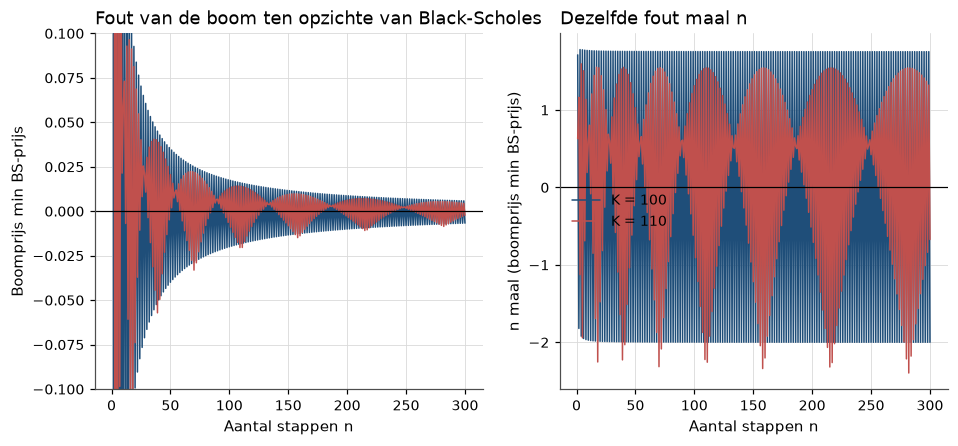

In [6]:
n_grid = np.arange(1, 301)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for K, color in [(100.0, hap.plotting.COLORS[0]), (110.0, hap.plotting.COLORS[1])]:
    bs = bs_call(S0, K, T_opt, r_opt, sigma_opt)
    err = np.array([crr_call(S0, K, T_opt, r_opt, sigma_opt, n) for n in n_grid]) - bs
    axes[0].plot(n_grid, err, lw=1.0, color=color, label=f"K = {K:.0f}")
    axes[1].plot(n_grid, n_grid * err, lw=1.0, color=color, label=f"K = {K:.0f}")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_ylim(-0.1, 0.1)
axes[0].set_title("Fout van de boom ten opzichte van Black-Scholes")
axes[0].set_xlabel("Aantal stappen n")
axes[0].set_ylabel("Boomprijs min BS-prijs")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Dezelfde fout maal n")
axes[1].set_xlabel("Aantal stappen n")
axes[1].set_ylabel("n maal (boomprijs min BS-prijs)")
axes[1].legend()
plt.show()

:::{figure} #cel-apt-no-arbitrage-crr
:label: fig-apt-no-arbitrage-crr
:width: 95%

Links: de boom convergeert, maar niet monotoon. Voor de at-the-money call
($K = 100$) wisselt de fout van teken tussen even en oneven $n$, omdat bij even
$n$ een knoop precies op $S_0 = K$ valt en bij oneven $n$ niet. Voor $K = 110$
is het patroon onregelmatiger: de afstand van de uitoefenprijs tot de
dichtstbijzijnde knoop varieert met $n$. Rechts: vermenigvuldigd met $n$ blijft
de fout begrensd, dus de convergentie is van orde $1/n$, niet sneller.
:::

Met honderd stappen zit de boom binnen twee cent van Black-Scholes op een optie
van ruim tien euro, met duizend stappen binnen een vijfde cent;
[](#ex-apt-no-arbitrage-2) laat zien dat middelen over twee opeenvolgende $n$ de
oscillatie grotendeels wegwerkt.

### Pricing errors: losse aandelen tegenover gespreide portefeuilles

Nu de APT met ruis. We simuleren $N$ aandelen met $K = 3$ factorrendementen
(maandvolatiliteit 4,5%, 3% en 3%; premies 0,5%, 0,3% en 0,3% per maand),
loadings $\beta_{i,1} \sim \mathcal{N}(1;\ 0{,}3^2)$ en $\beta_{i,2}, \beta_{i,3}
\sim \mathcal{N}(0;\ 0{,}5^2)$, en idiosyncratische ruis met 8% per maand. Twintig aandelen zijn
verkeerd geprijsd met een alpha van 1% per maand, 12% per jaar. Alle andere hebben alpha nul. Dat is een wereld die aan de
Huberman-grens voldoet: $\sum_i \alpha_i^2 = 20 \times 0{,}01^2 = 0{,}002$,
ongeacht $N$. We schatten de alpha's met tijdreeksregressies op $T = 120$
maanden, tien jaar data, en herhalen dat honderd keer per $N$.

In [7]:
def simulate_pricing_errors(N, T=120, n_rep=100, n_bad=20, alpha_bad=0.01, sigma_eps=0.08):
    """Estimate alphas of N stocks, 20 of them mispriced, on T months of data.

    Returns the rejection rates of individual alphas and the true and estimated
    alpha of the equal-weighted portfolio across n_rep samples.
    """
    lam = np.array([0.005, 0.003, 0.003])
    vol = np.array([0.045, 0.030, 0.030])
    B = np.column_stack([rng.normal(1.0, 0.3, N), rng.normal(0.0, 0.5, (N, 2))])
    alpha = np.zeros(N)
    alpha[:n_bad] = alpha_bad
    reject_bad, reject_good, alpha_ew_hat = [], [], []
    for _ in range(n_rep):
        f = lam + vol * rng.standard_normal((T, 3))
        excess = alpha + f @ B.T + sigma_eps * rng.standard_normal((T, N))
        design = np.column_stack([np.ones(T), f])
        coef, *_ = np.linalg.lstsq(design, excess, rcond=None)
        resid = excess - design @ coef
        se = np.sqrt((resid**2).sum(axis=0) / (T - 4) * np.linalg.inv(design.T @ design)[0, 0])
        t_alpha = coef[0] / se
        reject_bad.append(np.mean(np.abs(t_alpha[:n_bad]) > 1.96))
        reject_good.append(np.mean(np.abs(t_alpha[n_bad:]) > 1.96))
        alpha_ew_hat.append(coef[0].mean())
    return {
        "N": N,
        "sum alpha^2": float(alpha @ alpha),
        "RMS alpha": float(np.sqrt(alpha @ alpha / N)),
        "alpha EW (waar)": float(alpha.mean()),
        "SD alpha-hat EW": float(np.std(alpha_ew_hat)),
        "SE alpha-hat aandeel": float(se.mean()),
        "verwerpt |t|>1.96, fout geprijsd": float(np.mean(reject_bad)),
        "verwerpt |t|>1.96, goed geprijsd": float(np.mean(reject_good)),
    }


N_grid = [25, 50, 100, 200, 400, 800, 1600, 3200]
pricing = pd.DataFrame([simulate_pricing_errors(N) for N in N_grid]).set_index("N")
pricing.round(4)

,sum alpha^2,RMS alpha,alpha EW (waar),SD alpha-hat EW,SE alpha-hat aandeel,"verwerpt |t|>1.96, fout geprijsd","verwerpt |t|>1.96, goed geprijsd"
N,,,,,,,
25,0.002,0.0089,0.0080,0.0016,0.0077,0.2565,0.0560
50,0.002,0.0063,0.0040,0.0011,0.0076,0.2690,0.0583
100,0.002,0.0045,0.0020,0.0009,0.0076,0.2820,0.0551
200,0.002,0.0032,0.0010,0.0005,0.0074,0.2650,0.0507
400,0.002,0.0022,0.0005,0.0004,0.0075,0.2695,0.0515
800,0.002,0.0016,0.0002,0.0003,0.0073,0.2695,0.0529
1600,0.002,0.0011,0.0001,0.0002,0.0076,0.2805,0.0518
3200,0.002,0.0008,0.0001,0.0001,0.0076,0.2840,0.0522


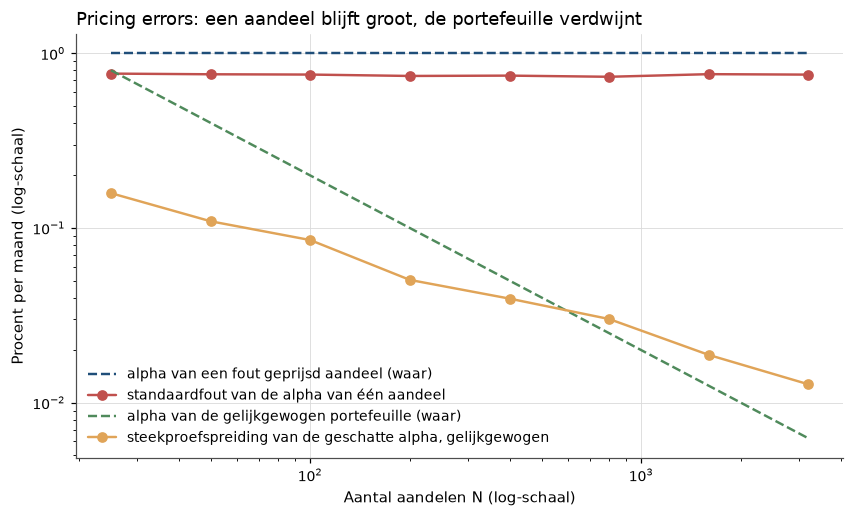

In [8]:
fig, ax = plt.subplots()
ax.plot(pricing.index, np.full(len(pricing), 0.01) * 100, ls="--",
        label="alpha van een fout geprijsd aandeel (waar)")
ax.plot(pricing.index, pricing["SE alpha-hat aandeel"] * 100, marker="o",
        label="standaardfout van de alpha van één aandeel")
ax.plot(pricing.index, pricing["alpha EW (waar)"] * 100, ls="--",
        label="alpha van de gelijkgewogen portefeuille (waar)")
ax.plot(pricing.index, pricing["SD alpha-hat EW"] * 100, marker="o",
        label="steekproefspreiding van de geschatte alpha, gelijkgewogen")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Aantal aandelen N (log-schaal)")
ax.set_ylabel("Procent per maand (log-schaal)")
ax.set_title("Pricing errors: een aandeel blijft groot, de portefeuille verdwijnt")
ax.legend()
plt.show()

:::{figure} #cel-apt-no-arbitrage-pricing
:label: fig-apt-no-arbitrage-pricing
:width: 90%

Bovenste twee lijnen: de twintig fout geprijsde aandelen houden hun alpha van 1%
per maand, maar met tien jaar data is de standaardfout van die alpha 0,75%, hoe
groot $N$ ook is. Onderste twee lijnen: de ware alpha van de gelijkgewogen
portefeuille, $0{,}2/N$, daalt met $1/N$, de schattingsfout met $1/\sqrt{N}$.
Voor gespreide portefeuilles zijn zowel de pricing error als de onzekerheid
erover klein; voor een los aandeel zijn beide groot.
:::

De tabel is het 2%-motief in zijn scherpste vorm. Een alpha van 12% per jaar op
één aandeel wordt met tien jaar maanddata in ruim een kwart van de steekproeven
significant gevonden. Bij de goed geprijsde aandelen verwerpt de toets in 5% van
de gevallen, zoals het hoort: met 3200 aandelen ruim 150 valse ontdekkingen
tegenover gemiddeld vijf à zes echte. De som van de gekwadrateerde pricing
errors blijft $0{,}002$, maar hun RMS zakt van 0,89% bij $N = 25$ naar 0,08% bij
$N = 3200$, precies zoals [](#eq-apt-no-arbitrage-huberman) toestaat. De APT
verbiedt niet dat er aan één aandeel iets te verdienen valt; zij verbiedt dat het
zonder risico te verdienen valt.

### Principale componenten bij vaste T en groeiende N

De laatste simulatie toetst [](#eq-apt-no-arbitrage-ck). We houden $T = 60$
maanden vast en laten $N$ groeien van 10 tot 3000 aandelen. De eigen ruis heeft
een benaderende, geen strikte, factorstructuur: aandelen zitten in bedrijfstakken
van tien stuks, en binnen een bedrijfstak is de correlatie van de eigen ruis 0,3.
De grootste eigenwaarde van $\mathbf{V}$ is dan $\sigma^2_\varepsilon(0{,}7 + 0{,}3
\times 10) = 3{,}7\,\sigma^2_\varepsilon$, begrensd in $N$ zoals
{cite:t}`ChamberlainRothschild1983` eisen. Per $N$ schatten we de factoren met de
$K = 3$ grootste eigenvectoren van de $T \times T$-matrix $\mathbf{R}\mathbf{R}'/N$
en meten we hoeveel van elke ware factor ze verklaren ($R^2$ van de ware factor op
de drie geschatte componenten), gemiddeld over vijftig steekproeven.

In [9]:
def pca_recovery(N, T=60, K=3, n_rep=50, block=10, rho=0.3, sigma_eps=0.08):
    """R^2 of each true factor on the K asymptotic principal components.

    Idiosyncratic returns are correlated within industries of `block` stocks,
    an approximate (not strict) factor structure. Returns the mean R^2 per
    factor and the eigenvalues of R R'/N from the last replication.
    """
    vol = np.array([0.045, 0.030, 0.030])
    r2 = np.empty((n_rep, K))
    for rep in range(n_rep):
        B = np.column_stack([rng.normal(1.0, 0.3, N), rng.normal(0.0, 0.5, (N, 2))])
        f = vol * rng.standard_normal((T, K))
        industry = rng.standard_normal((T, -(-N // block)))[:, np.arange(N) // block]
        eps = sigma_eps * (np.sqrt(rho) * industry
                           + np.sqrt(1 - rho) * rng.standard_normal((T, N)))
        R = f @ B.T + eps
        R -= R.mean(axis=0)
        eigval, eigvec = np.linalg.eigh(R @ R.T / N)
        G = eigvec[:, -K:]
        fc = f - f.mean(axis=0)
        r2[rep] = ((G.T @ fc) ** 2).sum(axis=0) / (fc**2).sum(axis=0)
    return r2.mean(axis=0), eigval[::-1]


recovery, spectra = {}, {}
for N in [10, 30, 100, 300, 1000, 3000]:
    recovery[N], spectra[N] = pca_recovery(N)

pd.DataFrame(recovery, index=["R2 factor 1", "R2 factor 2", "R2 factor 3"]).T.rename_axis(
    "N").round(3)

,R2 factor 1,R2 factor 2,R2 factor 3
N,,,
10,0.518,0.237,0.233
30,0.732,0.123,0.128
100,0.910,0.363,0.349
300,0.967,0.723,0.773
1000,0.989,0.942,0.946
3000,0.997,0.983,0.981


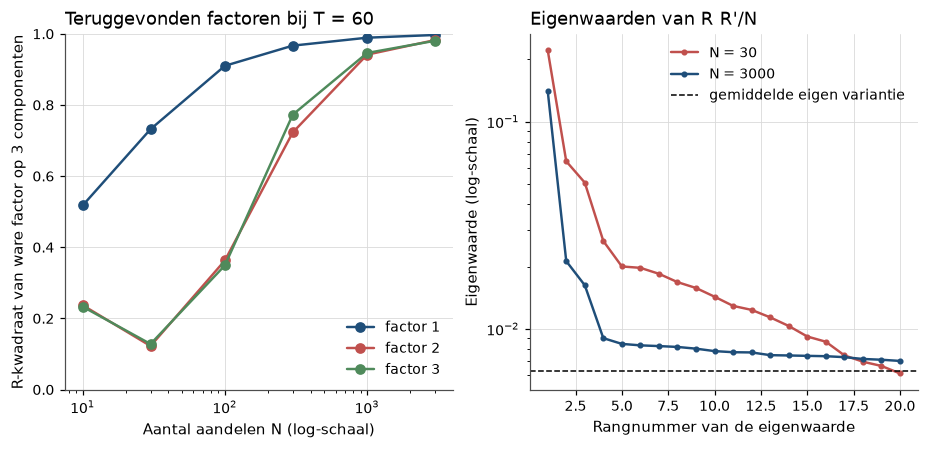

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
rec = pd.DataFrame(recovery, index=["factor 1", "factor 2", "factor 3"]).T
for col in rec.columns:
    axes[0].plot(rec.index, rec[col], marker="o", label=col)
axes[0].set_xscale("log")
axes[0].set_ylim(0, 1)
axes[0].set_title("Teruggevonden factoren bij T = 60")
axes[0].set_xlabel("Aantal aandelen N (log-schaal)")
axes[0].set_ylabel("R-kwadraat van ware factor op 3 componenten")
axes[0].legend()
for N, color in [(30, hap.plotting.COLORS[1]), (3000, hap.plotting.COLORS[0])]:
    axes[1].plot(np.arange(1, 21), spectra[N][:20], marker="o", ms=3, color=color,
                 label=f"N = {N}")
axes[1].axhline(0.08**2 * 59 / 60, color="black", ls="--", lw=1,
                label="gemiddelde eigen variantie")
axes[1].set_yscale("log")
axes[1].set_title("Eigenwaarden van R R'/N")
axes[1].set_xlabel("Rangnummer van de eigenwaarde")
axes[1].set_ylabel("Eigenwaarde (log-schaal)")
axes[1].legend()
plt.show()

:::{figure} #cel-apt-no-arbitrage-pca
:label: fig-apt-no-arbitrage-pca
:width: 95%

Links: met dertig aandelen en vijf jaar data vinden de componenten de
marktfactor redelijk terug ($R^2 \approx 0{,}73$), maar de twee zwakkere factoren
nauwelijks ($0{,}12$); met drieduizend aandelen alle drie met $R^2 \approx 0{,}98$,
terwijl $T$ niet veranderd is. Rechts: bij $N = 3000$ steken drie eigenwaarden
uit boven een vlakke bulk net boven de gemiddelde idiosyncratische variantie —
de toets op het aantal factoren van Connor en Korajczyk in één plaatje. Bij
$N = 30$ dalen de eigenwaarden geleidelijk en is de grens tussen factor en ruis
niet te zien.
:::

Dit is de keerzijde van het 2%-motief. De standaardfout van de alpha van één
aandeel was bij $N = 3200$ dezelfde als bij $N = 25$, maar *covarianties* worden
met meer aandelen wél beter gemeten. De factorstructuur openbaart zich in de
cross-sectie, zelfs in vijf jaar data; de premies op die factoren alleen in de
tijdreeks, en daar helpt $N$ niet.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Richard Roll en Stephen Ross, *An Empirical Investigation of the
Arbitrage Pricing Theory*, Journal of Finance 1980 {cite}`RollRoss1980`, met de
asymptotische principale componenten van {cite:t}`ConnorKorajczyk1986` en
{cite:t}`ChamberlainRothschild1983` als schatter.

**Wat.** De kernbevinding in de samenvatting van Roll en Ross, letterlijk:
*"Using data for individual equities during the 1962-72 period, at least three
and probably four 'priced' factors are found in the generating process of
returns."* Volgens het overzicht van {cite:t}`ConnorKorajczyk1995` gebruikten zij
dagrendementen van 1260 aandelen van juli 1962 tot december 1972, verdeeld in 42
groepen van dertig, schatten per groep een vijf-factormodel met maximum-
likelihood-factoranalyse, en schatten de premies met cross-sectionele GLS-
regressies à la Fama-MacBeth. Wij repliceren de *vorm* van die analyse — hoeveel
statistische factoren, en of ze een premie dragen — en vergelijken de factoren
met Mkt, SMB en HML van {cite:t}`FamaFrench1993`.

**Data hier.** Kenneth French Data Library via `hap.data.french`: de 25
value-weighted size/BM-portefeuilles (`"25_Portfolios_5x5"`) en de drie
factoren (`"F-F_Research_Data_Factors"`), maandelijks, 1963-07 tot het einde van
de snapshot, in excess van de risicovrije rente uit hetzelfde bestand.

**Verschil met het origineel.** Roll en Ross gebruikten individuele aandelen,
dagdata, factoranalyse en GLS; wij 25 portefeuilles, maanddata, principale
componenten en OLS, met bèta's uit de volle steekproef. Met $N = 25$ zijn we ver
van de asymptotiek in $N$, en de portefeuilles zijn gesorteerd op precies de
kenmerken waarvan we de factoren terug willen vinden: een voordeel voor de
vergelijking met SMB en HML, een waarschuwing voor elke conclusie over "het"
aantal factoren. Hun steekproef eindigt in 1972, de onze loopt van 1963 tot heden.

**Verwachte afwijking.** De eerste component verklaart meer dan 75% van de totale
variantie en correleert meer dan 0,9 met Mkt-RF. De eerste drie componenten
samen verklaren SMB en HML elk met een $R^2$ boven 0,85, maar de tweede en derde
component zijn afzonderlijk *geen* SMB en HML: ze zijn een rotatie ervan.
Omgekeerd verklaren Mkt, SMB en HML samen elk van de drie componenten met een
$R^2$ boven 0,85. Wijkt de eerste uitspraak af, dan zit er een fout in de code;
de tweede en derde zijn het eigenlijke empirische resultaat.
```

In [11]:
ports = hap_data.french("25_Portfolios_5x5")
ff3 = hap_data.french("F-F_Research_Data_Factors")
sample = ports.join(ff3, how="inner").loc["1963-07":]
excess = sample[ports.columns].sub(sample["RF"], axis=0)
factors = sample[["Mkt-RF", "SMB", "HML"]]
assert excess.notna().all().all()

pd.Series({"begin": f"{excess.index[0]:%Y-%m}", "eind": f"{excess.index[-1]:%Y-%m}",
           "T (maanden)": len(excess), "N (portefeuilles)": excess.shape[1]})

begin                1963-07
eind                 2026-07
T (maanden)              757
N (portefeuilles)         25
dtype: object

We ontbinden de steekproefcovariantiematrix van de 25 excess rendementen. Een
eigenvector is op een schaalfactor na bepaald; we schalen de eerste zo dat de
gewichten optellen tot één (een gewone, lange portefeuille) en de hogere zo dat
de absolute gewichten optellen tot twee (ruwweg één euro long en één euro short).
Het teken kiezen we zodat de eerste component positief correleert met de markt
en de tweede en derde met HML.

In [12]:
eigval, eigvec = np.linalg.eigh(np.cov(excess.to_numpy(), rowvar=False))
order = np.argsort(eigval)[::-1]
eigval, eigvec = eigval[order], eigvec[:, order]

n_pc = 5
pc_names = [f"PC{k}" for k in range(1, n_pc + 1)]
weights = eigvec[:, :n_pc] / np.r_[eigvec[:, 0].sum(), np.abs(eigvec[:, 1:n_pc]).sum(axis=0) / 2]
pcs = pd.DataFrame(excess.to_numpy() @ weights, index=excess.index, columns=pc_names)
for k, name in enumerate(pc_names):
    anchor = factors["Mkt-RF"] if k == 0 else factors["HML"]
    if pcs[name].corr(anchor) < 0:
        pcs[name] *= -1
        weights[:, k] *= -1

pd.DataFrame(
    {"eigenwaarde": eigval[:n_pc], "aandeel variantie": eigval[:n_pc] / eigval.sum(),
     "cumulatief": np.cumsum(eigval[:n_pc]) / eigval.sum()},
    index=pc_names,
).round(4)

,eigenwaarde,aandeel variantie,cumulatief
PC1,0.0691,0.8329,0.8329
PC2,0.0052,0.0630,0.8958
PC3,0.0029,0.0350,0.9309
PC4,0.0011,0.0135,0.9443
PC5,0.0006,0.0073,0.9516


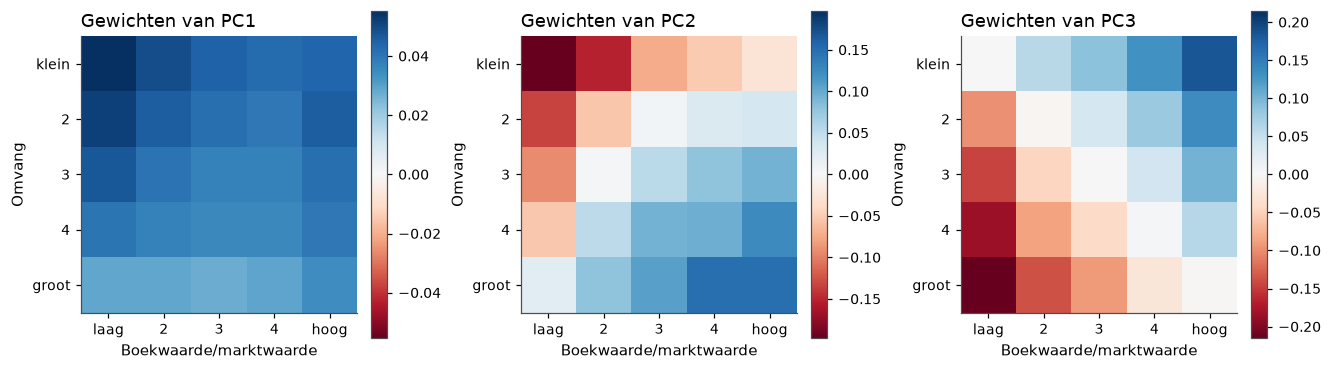

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), layout="constrained")
for k, ax in enumerate(axes):
    grid = weights[:, k].reshape(5, 5)
    bound = np.abs(grid).max()
    image = ax.imshow(grid, cmap="RdBu", vmin=-bound, vmax=bound)
    ax.set_xticks(range(5), ["laag", "2", "3", "4", "hoog"])
    ax.set_yticks(range(5), ["klein", "2", "3", "4", "groot"])
    ax.grid(False)
    ax.set_title(f"Gewichten van PC{k + 1}")
    ax.set_xlabel("Boekwaarde/marktwaarde")
    ax.set_ylabel("Omvang")
    fig.colorbar(image, ax=ax, shrink=0.8)
plt.show()

:::{figure} #cel-apt-no-arbitrage-loadings
:label: fig-apt-no-arbitrage-loadings
:width: 100%

Portefeuillegewichten van de eerste drie principale componenten over het
5×5-raster (rijen: omvang, kolommen: boekwaarde/marktwaarde). De eerste
component is long in alle 25 portefeuilles, iets zwaarder in kleine aandelen: een
marktportefeuille. De tweede is short in klein-groei en long in groot-waarde, de
derde long in klein-waarde en short in groot-groei. Hun gradiënten lopen langs
de diagonalen van het raster: value-min-size en value-plus-size, geen zuivere SMB
of HML.
:::

In [14]:
pd.concat([pcs.iloc[:, :3], factors], axis=1).corr().loc[pc_names[:3], factors.columns].round(3)

,Mkt-RF,SMB,HML
PC1,0.926,0.581,-0.070
PC2,0.128,-0.624,0.644
PC3,-0.305,0.439,0.723


In [15]:
def r_squared(y, X):
    """R^2 of an OLS regression of y on X with an intercept."""
    design = np.column_stack([np.ones(len(X)), X])
    coef, *_ = np.linalg.lstsq(design, y, rcond=None)
    resid = y - design @ coef
    return 1 - resid @ resid / ((y - y.mean()) @ (y - y.mean()))


pcs3 = pcs.iloc[:, :3]
pd.Series(
    {**{f"{c} op PC1, PC2, PC3": r_squared(factors[c].to_numpy(), pcs3.to_numpy())
        for c in factors.columns},
     **{f"{c} op Mkt-RF, SMB, HML": r_squared(pcs3[c].to_numpy(), factors.to_numpy())
        for c in pcs3.columns}},
    name="R-kwadraat",
).round(3)

Mkt-RF op PC1, PC2, PC3    0.967
SMB op PC1, PC2, PC3       0.920
HML op PC1, PC2, PC3       0.943
PC1 op Mkt-RF, SMB, HML    0.988
PC2 op Mkt-RF, SMB, HML    0.893
PC3 op Mkt-RF, SMB, HML    0.919
Name: R-kwadraat, dtype: float64

PC1 correleert 0,93 met de markt; PC2 en PC3 hangen elk met zowel SMB als HML
samen. Dat is geen gebrek maar een rotatie: de drie componenten verklaren Mkt,
SMB en HML voor 97%, 92% en 94%, en omgekeerd verklaren de French-factoren de
componenten voor 99%, 89% en 92%. De principale componenten weten niets van
boekwaarden of marktkapitalisaties; ze zien alleen covarianties, en daarin zitten
drie dominante richtingen die grotendeels de ruimte opspannen van de factoren die
Fama en French in 1993 met de hand construeerden.

Nu de premies. Omdat de componenten zelf portefeuilles van excess rendementen
zijn, is hun verwachte rendement direct de premie, en het gemiddelde met zijn
standaardfout is de eerste schatting. De tweede is de cross-sectionele
schatting van Roll en Ross: tijdreeksbèta's van de 25 portefeuilles op de eerste
$K$ componenten, en daarna maandelijkse cross-sectionele regressies van excess
rendementen op die bèta's.

In [16]:
ts = hap.summary_stats(pd.concat([pcs, factors], axis=1))[["mean", "se_mean"]].astype(float)
ts["t"] = ts["mean"] / ts["se_mean"]
(ts[["mean", "se_mean"]] * 100).assign(t=ts["t"]).rename(
    columns={"mean": "gemiddelde (%/mnd)", "se_mean": "SE (%/mnd)", "t": "t-waarde"}).round(3)

,gemiddelde (%/mnd),SE (%/mnd),t-waarde
PC1,0.764,0.194,3.938
PC2,0.366,0.124,2.964
PC3,0.212,0.099,2.150
PC4,-0.132,0.071,-1.868
PC5,-0.019,0.044,-0.422
Mkt-RF,0.599,0.162,3.696
SMB,0.147,0.110,1.343
HML,0.299,0.108,2.771


In [17]:
def two_pass(test_excess, factor_returns):
    """Full-sample betas, then monthly cross-sectional OLS regressions on them.

    Same estimates as hap.fama_macbeth(..., lags=0) with constant betas, but
    vectorised: all T cross-sections are solved in one least-squares call.
    """
    # TODO: naar hap.stats (hap.fama_macbeth loops over dates with statsmodels, ~25 s per call here)
    R = test_excess.to_numpy()
    F = factor_returns.to_numpy()
    coef, *_ = np.linalg.lstsq(np.column_stack([np.ones(len(F)), F]), R, rcond=None)
    Z = np.column_stack([np.ones(R.shape[1]), coef[1:].T])   # N x (K+1): constant and betas
    gammas = np.linalg.lstsq(Z, R.T, rcond=None)[0].T         # T x (K+1): monthly slopes
    estimate = gammas.mean(axis=0)
    se = gammas.std(axis=0, ddof=1) / np.sqrt(len(gammas))
    return pd.DataFrame({"estimate": estimate, "se": se, "tstat": estimate / se},
                        index=["constante", *factor_returns.columns])


t_values = pd.DataFrame({f"K = {K}": two_pass(excess, pcs.iloc[:, :K])["tstat"]
                         for K in range(1, n_pc + 1)}).reindex(["constante", *pc_names])
t_values.round(2)

,K = 1,K = 2,K = 3,K = 4,K = 5
constante,2.70,-0.24,3.90,3.88,5.79
PC1,0.12,2.40,-0.26,-0.24,-2.35
PC2,NaN,2.49,0.60,0.61,-0.96
PC3,NaN,NaN,3.30,3.30,4.25
PC4,NaN,NaN,NaN,-1.85,-1.83
PC5,NaN,NaN,NaN,NaN,3.24


In [18]:
fm_pc3 = two_pass(excess, pcs.iloc[:, :3])
fm_ff3 = two_pass(excess, factors)
alpha_tests = {name: hap.grs_test(excess, f) for name, f in
               [("PC1-3", pcs.iloc[:, :3]), ("Mkt, SMB, HML", factors)]}

pd.DataFrame({
    "PC1-3": [*(fm_pc3["estimate"] * 100), alpha_tests["PC1-3"]["mean_abs_alpha"] * 100,
              alpha_tests["PC1-3"]["grs"], alpha_tests["PC1-3"]["pvalue"]],
    "Mkt, SMB, HML": [*(fm_ff3["estimate"] * 100), alpha_tests["Mkt, SMB, HML"]["mean_abs_alpha"] * 100,
                      alpha_tests["Mkt, SMB, HML"]["grs"], alpha_tests["Mkt, SMB, HML"]["pvalue"]],
}, index=["constante (%/mnd)", "premie factor 1 (%/mnd)", "premie factor 2 (%/mnd)",
          "premie factor 3 (%/mnd)", "gem. |alpha| (%/mnd)", "GRS", "p-waarde GRS"]).round(3)

,PC1-3,"Mkt, SMB, HML"
constante (%/mnd),0.838,1.155
premie factor 1 (%/mnd),-0.074,-0.545
premie factor 2 (%/mnd),0.086,0.115
premie factor 3 (%/mnd),0.345,0.331
gem. |alpha| (%/mnd),0.088,0.087
GRS,3.475,3.629
p-waarde GRS,0.000,0.000


Eerst de tijdreeks. PC1 verdient 0,76% per maand ($t = 3{,}9$), iets meer dan
Mkt-RF (0,60%, $t = 3{,}7$), omdat zij kleine aandelen zwaarder weegt. De
standaardfout is 0,19% per maand, ruim 2% per jaar: ook met 757 maanden ken je
de premie niet tot op het procentpunt. PC2 en PC3 hebben significante
gemiddelden ($t = 3{,}0$ en $2{,}2$), PC4 en PC5 niet. Dan de cross-sectie van
Roll en Ross. Met alleen PC1 is de constante significant ($t = 2{,}7$) en de
premie op PC1 nul ($t = 0{,}1$): de security market line van [](#02-08-capm) is
ook hier vlak. Met drie componenten is de constante 0,84% per maand
($t = 3{,}9$) en draagt alleen PC3 een significante premie (0,35%, $t = 3{,}3$),
ruim boven haar tijdreeksgemiddelde van 0,21%. Mkt, SMB en HML doen het niet
beter: een constante van ruim 1,1% per maand, een negatieve marktpremie, en
alleen HML significant. Beide modellen laten een gemiddelde absolute alpha van
0,09% per maand over en worden door de GRS-toets verworpen ($p < 0{,}001$).

Hoeveel geprijsde factoren? Het aantal significante premies in de cross-sectie
is achtereenvolgens 0, 2, 1, 1 en 3 voor $K = 1, \dots, 5$, en de constante komt
alleen bij $K = 2$ in de buurt van nul; in de tijdreeks zijn het er drie. Roll en
Ross vonden "at least three and probably four" in individuele aandelen; wij
vinden met deze test-assets een getal dat van de toets en van $K$ afhangt. Dat is
geen falen van de replicatie, maar precies het punt van hun critici.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** De fundamentele stelling is geen model dat kan
breken maar de grammatica waarin elk later model geschreven is: zij verklaart
waarom een optie een prijs heeft zonder nutsfunctie, waarom risiconeutraal
rekenen werkt, en waarom $p = \E[mx]$ met positieve $m$ een gevolg is van het
ontbreken van gratis geld. De APT voegt een voorspelling toe die in de data
overeind blijft: een paar richtingen van covariantie domineren de cross-sectie,
principale componenten vinden ze terug, en in onze 25 portefeuilles zijn het
markt, size en value. Factorblootstelling is sindsdien de taal van risicomodellen.

**Waar het breekt.** Twee plekken. De eerste is theoretisch.
{cite:t}`Shanken1982` liet zien dat de Huberman-grens niet invariant is voor het
herverpakken van activa in portefeuilles: dezelfde economie kan in de ene
verzameling test-assets aan de grens voldoen en in een lineaire transformatie
ervan niet. Een grens op een oneindige som valt met eindige data niet te toetsen,
en een factorstructuur met een willekeurig aantal factoren past op alles.
{cite:t}`DybvigRoss1985` antwoordden dat de APT als *exacte* benadering voor goed
gespreide portefeuilles wel degelijk verwerpbaar is, en dat het CAPM met de
onwaarneembare marktportefeuille van {cite:t}`Roll1977` er niet beter voor staat. De
tweede plek is de replicatie hierboven: de theorie zegt niet welke factoren en
hoeveel, en op 25 portefeuilles is het antwoord op "hoeveel geprijsd?" een
functie van de toets die je kiest. Het concrete, meetbare feit: drie componenten
verklaren 93% van de variantie, maar laten een constante van 0,84% per maand en
alpha's over die de GRS-toets verwerpt.

**Risico of vergissing?** De APT is neutraal. De Chicago-lezing: SMB en HML zijn
dominante richtingen van covariantie, dus niet te diversifiëren risico, en dat er
een premie op staat is precies wat de APT voorspelt. De Yale-lezing: als
beleggers systematisch te enthousiast zijn over groeiaandelen, beweegt die
vergissing alle groeiaandelen tegelijk, en ook dan is er een factor. Arbitrage
elimineert idiosyncratische mispricing, maar een *gemeenschappelijke* mispricing
wegarbitreren betekent het factorrisico dragen — en daar gelden de *limits of
arbitrage* (de grenzen aan wat arbitrageurs met beperkt kapitaal en een beperkte
horizon kunnen rechtzetten). Principale componenten zien covarianties, geen
motieven. Wat de kampen zou scheiden, is een premie zonder covariantie of een
covariantie zonder premie; die data zijn schaars, en de reeks komt er bij Fama
en French op terug.

**Wat er daarna kwam.** De fundamentele stelling garandeert een positieve SDF maar
wijst er geen aan; Lucas en Breeden gaven $m$ een economische inhoud door haar
aan consumptie te binden, in [](#03-12-consumptie-capm).

## Oefeningen

:::{exercise}
:label: ex-apt-no-arbitrage-1

**Een incomplete markt.** Voeg aan het toy-voorbeeld een derde toestand "midden"
toe. De obligatie keert $(1;\ 1;\ 1)$ uit in (goed, midden, slecht) en kost
$0{,}90$; het aandeel keert $(1{,}40;\ 1{,}00;\ 0{,}60)$ uit en kost $0{,}86$. De
call met $K = 1$ keert $(0{,}40;\ 0;\ 0)$ uit.

1. Bepaal met de hand alle strikt positieve toestandsprijzen die obligatie en
   aandeel correct prijzen. Laat zien dat het een lijnstuk is en geef de
   eindpunten.
2. Leid daaruit het interval van arbitragevrije callprijzen af.
3. Controleer het interval met `scipy.optimize.linprog` door $\mathbf{q}'\mathbf{y}$ te
   minimaliseren en te maximaliseren onder $\mathbf{X}'\mathbf{q} = \mathbf{p}$,
   $\mathbf{q} \geq \mathbf{0}$.
4. De call noteert $0{,}17$. Geef een expliciete arbitrage.
:::

:::{solution} ex-apt-no-arbitrage-1
:class: dropdown

**(1)** De voorwaarden zijn $q_g + q_m + q_s = 0{,}90$ en $1{,}40\,q_g + 1{,}00\,q_m +
0{,}60\,q_s = 0{,}86$. Trek de eerste van de tweede af:
$0{,}40\,q_g - 0{,}40\,q_s = -0{,}04$, dus $q_g = q_s - 0{,}10$. Invullen in de eerste:
$q_m = 1{,}00 - 2q_s$. Strikte positiviteit vraagt $q_s > 0{,}10$ en $q_s < 0{,}50$.
De toestandsprijzen vormen het open lijnstuk van $(0;\ 0{,}80;\ 0{,}10)$ naar
$(0{,}40;\ 0;\ 0{,}50)$, geparametriseerd door $q_s \in (0{,}10;\ 0{,}50)$.

**(2)** De callprijs is $0{,}40\,q_g = 0{,}40\,(q_s - 0{,}10) \in (0;\ 0{,}16)$.

**(3)**

In [19]:
X3 = np.array([[1.00, 1.40],
               [1.00, 1.00],
               [1.00, 0.60]])
p3 = np.array([0.90, 0.86])
call3 = np.array([0.40, 0.00, 0.00])

bounds = [optimize.linprog(sign * call3, A_eq=X3.T, b_eq=p3, bounds=[(0, None)] * 3)
          for sign in (1, -1)]
lower, upper = bounds[0].fun, -bounds[1].fun
super_rep = np.linalg.solve(np.array([[1.00, 1.40], [1.00, 0.60]]), np.array([0.40, 0.00]))

pd.Series({"ondergrens": lower, "bovengrens": upper,
           "q bij bovengrens (goed)": bounds[1].x[0], "q bij bovengrens (midden)": bounds[1].x[1],
           "q bij bovengrens (slecht)": bounds[1].x[2],
           "payoff super-replicatie (midden)": X3[1] @ super_rep,
           "kosten super-replicatie": p3 @ super_rep}).round(4)

ondergrens                          0.00
bovengrens                          0.16
q bij bovengrens (goed)             0.40
q bij bovengrens (midden)           0.00
q bij bovengrens (slecht)           0.50
payoff super-replicatie (midden)    0.20
kosten super-replicatie             0.16
dtype: float64

De grenzen zijn $0$ en $0{,}16$. De bovengrens wordt bereikt in de rand
$q_m = 0$, en is de kostprijs van de portefeuille "half aandeel, $0{,}3$ obligatie
short", die de call in goed en slecht exact namaakt en in midden $0{,}20$ extra
uitkeert: de super-replicatieprijs.

**(4)** Bij $0{,}17$: verkoop de call en koop de super-replicatie. Vandaag
$0{,}17 - 0{,}16 = 0{,}01$ ontvangen; morgen payoff $(0;\ 0{,}20;\ 0) \geq
\mathbf{0}$. Dat is een arbitrage in de zin van
[](#def-apt-no-arbitrage-begrippen) — zelfs een dubbele: geld vandaag en een
gratis loterijbriefje morgen.

De oefening laat zien wat [](#thm-apt-no-arbitrage-uniek) in de praktijk betekent:
zodra de markt incompleet is, bepaalt arbitrage geen prijs meer maar een
interval, en alles binnen dat interval is een uitspraak over *welke* SDF de markt
gebruikt.
:::

:::{exercise}
:label: ex-apt-no-arbitrage-2

**Oscillatie wegmiddelen.**

1. Laat met [](#thm-apt-no-arbitrage-fundamenteel) zien dat een één-stapsboom
   met factoren $u > d$ en bruto rente $R$ arbitragevrij is dan en slechts dan
   als $d < R < u$. Geef voor $R \geq u$ een expliciete arbitrage.
2. Bereken voor de at-the-money call uit de simulatie ($S = K = 100$, $T = 1$,
   $r = 5\%$, $\sigma = 20\%$) de fout ten opzichte van Black-Scholes voor
   $n = 100$, $n = 200$, en voor het gemiddelde van de prijzen bij $n = 100$ en
   $n = 101$. Welke route is goedkoper per procent nauwkeurigheid?
:::

:::{solution} ex-apt-no-arbitrage-2
:class: dropdown

**(1)** De payoffmatrix van obligatie en aandeel is
$\mathbf{X} = \begin{pmatrix} R & u \\ R & d \end{pmatrix}$ per euro, met prijzen
$(1, 1)$. Toestandsprijzen lossen $q_u + q_d = 1/R$ en $u\,q_u + d\,q_d = 1$ op, dus
$q_u = (1 - d/R)/(u - d)$ en $q_d = (u/R - 1)/(u - d)$. Beide zijn strikt
positief precies als $d < R < u$; door de stelling is dat equivalent met geen
arbitrage. Als $R \geq u$: verkoop een aandeel short en beleg de euro risicovrij.
Vandaag kosten nul; morgen $R - u \geq 0$ in de goede en $R - d > 0$ in de slechte
toestand.

**(2)**

In [20]:
bs_atm = bs_call(S0, 100.0, T_opt, r_opt, sigma_opt)
c100, c101, c200 = (crr_call(S0, 100.0, T_opt, r_opt, sigma_opt, n) for n in (100, 101, 200))
pd.Series({"fout n = 100": c100 - bs_atm, "fout n = 200": c200 - bs_atm,
           "fout gemiddelde n = 100, 101": (c100 + c101) / 2 - bs_atm}).round(5)

fout n = 100                   -0.01997
fout n = 200                   -0.00999
fout gemiddelde n = 100, 101   -0.00130
dtype: float64

Verdubbelen van het aantal stappen halveert de fout ruwweg, conform orde $1/n$.
Het gemiddelde van twee opeenvolgende $n$ kost ongeveer evenveel rekenwerk als
$n = 200$, maar de fout is bijna acht keer kleiner (0,0013 tegen 0,0100), omdat de
leidende term van de fout van teken wisselt tussen even en oneven $n$. De les
voor het hoofdargument: de boom is een arbitragevrije economie die in verdeling
naar Black-Scholes convergeert, en het convergentiepatroon is een eigenschap van
het rooster, niet van de economie.
:::

:::{exercise}
:label: ex-apt-no-arbitrage-3

**Andere test-assets.** Herhaal de principale-componentenanalyse van de
replicatie op de 49 bedrijfstakportefeuilles van French
(`hap_data.french("49_Industry_Portfolios")`), vanaf 1969-07 en met alleen de
bedrijfstakken zonder ontbrekende waarden.

1. Welk deel van de variantie verklaart de eerste component, en welk de eerste
   drie?
2. Wat is de $R^2$ van Mkt-RF, SMB en HML op de eerste drie componenten?
3. Wat zegt het verschil met de 25 size/BM-portefeuilles over de vraag "hoeveel
   factoren heeft de economie"?
:::

:::{solution} ex-apt-no-arbitrage-3
:class: dropdown

In [21]:
industries = hap_data.french("49_Industry_Portfolios")
ind = industries.join(ff3, how="inner").loc["1969-07":]
ind_excess = ind[industries.columns].dropna(axis=1).sub(ind["RF"], axis=0)
ind_factors = ind[["Mkt-RF", "SMB", "HML"]]

val, vec = np.linalg.eigh(np.cov(ind_excess.to_numpy(), rowvar=False))
val, vec = val[::-1], vec[:, ::-1]
ind_pcs = ind_excess.to_numpy() @ vec[:, :3]

pd.Series({
    "aantal bedrijfstakken": ind_excess.shape[1],
    "aandeel variantie PC1": val[0] / val.sum(),
    "aandeel variantie PC1-3": val[:3].sum() / val.sum(),
    **{f"R2 {c} op PC1-3": r_squared(ind_factors[c].to_numpy(), ind_pcs)
       for c in ind_factors.columns},
}).round(3)

aantal bedrijfstakken      49.000
aandeel variantie PC1       0.552
aandeel variantie PC1-3     0.655
R2 Mkt-RF op PC1-3          0.917
R2 SMB op PC1-3             0.170
R2 HML op PC1-3             0.027
dtype: float64

De eerste component is ook hier de markt ($R^2$ van Mkt-RF op de eerste drie
componenten 0,92), maar zij verklaart 55% van de variantie tegen 83% bij de
size/BM-portefeuilles, en de eerste drie componenten verklaren SMB voor 17% en
HML voor 3%. Bedrijfstakken zijn niet op omvang en boekwaarde gesorteerd; hun
dominante richtingen zijn andere, vermoedelijk sectorcontrasten. Welke factoren
een PCA "vindt", is dus een eigenschap van de test-assets — de empirische kant
van de kritiek van {cite:t}`Shanken1982`.
:::